# Autograph Development - Part I
***111725JAA & Claude**
Development notebook for the `autograph.py` module. This notebook is used to test and develop the automated graph extraction and scattering calculation functionality independently from the GUI.

## Goals
1. Extract graph structure and numerical parameters from graph dictionaries
2. Compute spanning trees and identify chord edges
3. Validate scattering parameter assignments
4. Prepare data structures for matrix calculations

In [1]:
# Add the graphulator package to the path
import sys
from pathlib import Path

# Navigate to the src directory
graphulator_src = Path.cwd().parent.parent / 'src'
if str(graphulator_src) not in sys.path:
    sys.path.insert(0, str(graphulator_src))

print(f"Added to path: {graphulator_src}")

Added to path: /Users/joe/WORKWORKWORK.nosync/PROGRAMMING/PYTHON/my_packages/graphulator/src


In [2]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt

# Import autograph module
from graphulator.autograph import GraphExtractor, load_pgraph

# Display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Test Graph Creation

Create a simple test graph to verify the extraction functionality.

In [3]:
# Example workflow (uncomment when you have a .pgraph file):
# 
# # Load the file
# pgraph_data = load_pgraph("my_saved_graph.pgraph")
# 
# # Extract with GraphExtractor
# extractor = GraphExtractor()
# graph_data = extractor.extract_from_pgraph(pgraph_data, root_node_id=0)
# 
# # Validate
# validation = extractor.validate_scattering_assignments()
# if validation['missing_nodes']:
#     print("Missing node parameters:")
#     for msg in validation['missing_nodes']:
#         print(f"  - {msg}")
# if validation['missing_edges']:
#     print("Missing edge parameters:")
#     for msg in validation['missing_edges']:
#         print(f"  - {msg}")
#
# # Visualize (reuse visualization code from below)

print("Ready to load .pgraph files!")

Ready to load .pgraph files!


### Example: Complete workflow with .pgraph file

If you have a .pgraph file saved from the GUI with scattering assignments, you can load and extract it in one step:

In [4]:
# Method 1: Load with explicit filepath
# pgraph_data = load_pgraph("path/to/your/file.pgraph")

# Method 2: Load with file dialog (uncomment to use)
# pgraph_data = load_pgraph(use_dialog=True)

# Method 3: Load from Path object
# from pathlib import Path
# pgraph_data = load_pgraph(Path("graphs/my_graph.pgraph"))

print("To load a .pgraph file, uncomment one of the methods above")
print("Then you can extract it with:")
print("  extractor = GraphExtractor()")
print("  data = extractor.extract_from_pgraph(pgraph_data, root_node_id=0)")

To load a .pgraph file, uncomment one of the methods above
Then you can extract it with:
  extractor = GraphExtractor()
  data = extractor.extract_from_pgraph(pgraph_data, root_node_id=0)


## Loading .pgraph Files

The `load_pgraph()` function can load saved graph files directly from the GUI.

In [5]:
# Create a simple 3-node test graph
# Graph structure: a -- b -- c
#                  |_______|
# (Triangle with nodes a, b, c)

test_nodes = [
    {'node_id': 0, 'label': 'a', 'pos': (0.0, 0.0), 'conj': False},
    {'node_id': 1, 'label': 'b', 'pos': (1.0, 0.0), 'conj': False},
    {'node_id': 2, 'label': 'c', 'pos': (0.5, 0.866), 'conj': False}
]

test_edges = [
    {'from_node_id': 0, 'to_node_id': 1, 'is_self_loop': False},
    {'from_node_id': 1, 'to_node_id': 2, 'is_self_loop': False},
    {'from_node_id': 2, 'to_node_id': 0, 'is_self_loop': False}
]

# Create scattering assignments (using Python id() as keys)
test_scattering_assignments = {}

# Assign node parameters
for i, node in enumerate(test_nodes):
    test_scattering_assignments[id(node)] = {
        'freq': 5.0 + i * 0.5,
        'B_int': 1.0 + i * 0.2
    }

# Assign edge parameters
for i, edge in enumerate(test_edges):
    test_scattering_assignments[id(edge)] = {
        'f_p': 0.1 * (i + 1),
        'rate': 1.0,
        'phase': 0.0
    }

# Frequency settings
test_frequency_settings = {
    'start': 0.0,
    'stop': 10.0,
    'points': 100
}

print("Test graph created:")
print(f"  Nodes: {len(test_nodes)}")
print(f"  Edges: {len(test_edges)}")
print(f"  Scattering assignments: {len(test_scattering_assignments)}")

Test graph created:
  Nodes: 3
  Edges: 3
  Scattering assignments: 6


## Extract Graph Data

Use the `GraphExtractor` to extract and structure the graph data.

In [6]:
# Create extractor instance
extractor = GraphExtractor()

# Extract graph data (using node 0 as root)
graph_data = extractor.extract_graph_data(
    nodes=test_nodes,
    edges=test_edges,
    scattering_assignments=test_scattering_assignments,
    frequency_settings=test_frequency_settings,
    basis_order=None,  # Use nodes list order
    root_node_id=0     # Start spanning tree from node 0
)

print("Extracted graph data:")
print(f"  Nodes: {len(graph_data['nodes'])}")
print(f"  Edges: {len(graph_data['edges'])}")
print(f"  Tree edges: {graph_data['tree_edges']}")
print(f"  Chord edges: {graph_data['chord_edges']}")
print(f"  Root node ID: {graph_data['root_node_id']}")
print(f"  Is connected: {graph_data['is_connected']}")
print(f"  Frequency range: {graph_data['frequency']['start']} - {graph_data['frequency']['stop']}")

Extracted graph data:
  Nodes: 3
  Edges: 3
  Tree edges: [[0, 2], [1, 2]]
  Chord edges: [[0, 1]]
  Root node ID: 0
  Is connected: True
  Frequency range: 0.0 - 10.0


## Inspect Extracted Nodes

In [7]:
import json

print("Extracted nodes with scattering parameters:")
print(json.dumps(graph_data['nodes'], indent=2))

Extracted nodes with scattering parameters:
[
  {
    "node_id": 0,
    "label": "a",
    "pos": [
      0.0,
      0.0
    ],
    "conj": false,
    "freq": 5.0,
    "B_int": 1.0
  },
  {
    "node_id": 1,
    "label": "b",
    "pos": [
      1.0,
      0.0
    ],
    "conj": false,
    "freq": 5.5,
    "B_int": 1.2
  },
  {
    "node_id": 2,
    "label": "c",
    "pos": [
      0.5,
      0.866
    ],
    "conj": false,
    "freq": 6.0,
    "B_int": 1.4
  }
]


## Inspect Extracted Edges

In [8]:
print("Extracted edges with scattering parameters:")
print(json.dumps(graph_data['edges'], indent=2))

Extracted edges with scattering parameters:
[
  {
    "from_node_id": 0,
    "to_node_id": 1,
    "is_self_loop": false,
    "f_p": 0.1,
    "rate": 1.0,
    "phase": 0.0
  },
  {
    "from_node_id": 1,
    "to_node_id": 2,
    "is_self_loop": false,
    "f_p": 0.2,
    "rate": 1.0,
    "phase": 0.0
  },
  {
    "from_node_id": 2,
    "to_node_id": 0,
    "is_self_loop": false,
    "f_p": 0.30000000000000004,
    "rate": 1.0,
    "phase": 0.0
  }
]


## Validate Assignments

Check if all required scattering parameters are assigned.

In [9]:
validation_result = extractor.validate_scattering_assignments()

print("Validation Results:")
print("\nMissing node parameters:")
if validation_result['missing_nodes']:
    for msg in validation_result['missing_nodes']:
        print(f"  - {msg}")
else:
    print("  ✓ All nodes fully assigned")

print("\nMissing edge parameters:")
if validation_result['missing_edges']:
    for msg in validation_result['missing_edges']:
        print(f"  - {msg}")
else:
    print("  ✓ All edges fully assigned")

Validation Results:

Missing node parameters:
  ✓ All nodes fully assigned

Missing edge parameters:
  ✓ All edges fully assigned


## Visualize Graph Structure

Simple visualization of the extracted graph showing tree vs chord edges.

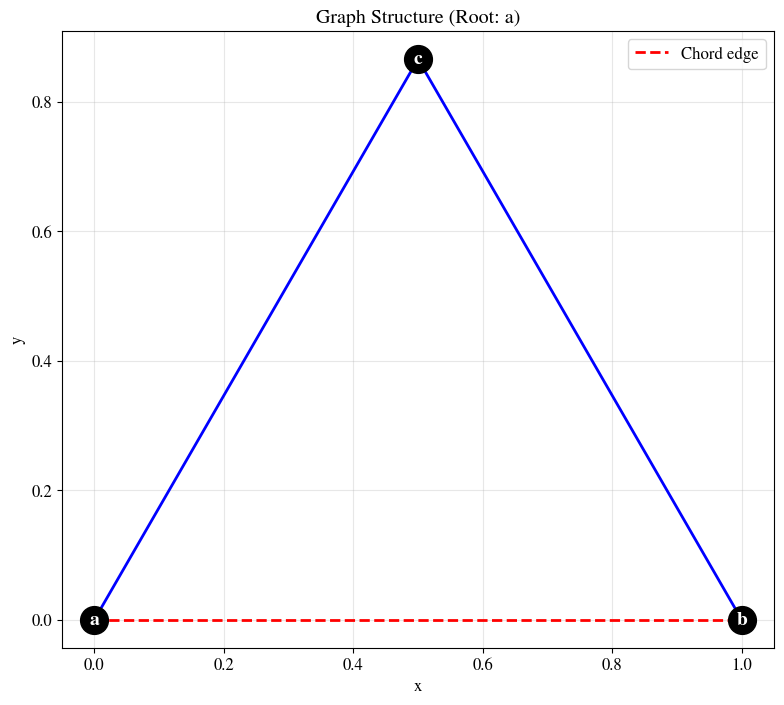

In [10]:
# Plot the graph structure
fig, ax = plt.subplots(figsize=(8, 8))

# Get node positions
node_positions = {node['node_id']: node['pos'] for node in graph_data['nodes']}
node_labels = {node['node_id']: node['label'] for node in graph_data['nodes']}

# Convert tree and chord edges to sets of tuples for easy lookup
tree_edge_set = set(tuple(sorted(e)) for e in graph_data['tree_edges'])
chord_edge_set = set(tuple(sorted(e)) for e in graph_data['chord_edges'])

# Draw edges
for edge in graph_data['edges']:
    from_id = edge['from_node_id']
    to_id = edge['to_node_id']
    edge_key = tuple(sorted([from_id, to_id]))
    
    from_pos = node_positions[from_id]
    to_pos = node_positions[to_id]
    
    if edge_key in tree_edge_set:
        # Tree edge - solid blue
        ax.plot([from_pos[0], to_pos[0]], [from_pos[1], to_pos[1]], 
                'b-', linewidth=2, label='Tree edge' if edge == graph_data['edges'][0] else '')
    elif edge_key in chord_edge_set:
        # Chord edge - dashed red
        ax.plot([from_pos[0], to_pos[0]], [from_pos[1], to_pos[1]], 
                'r--', linewidth=2, label='Chord edge')

# Draw nodes
for node_id, pos in node_positions.items():
    ax.plot(pos[0], pos[1], 'ko', markersize=20)
    ax.text(pos[0], pos[1], node_labels[node_id], 
            ha='center', va='center', color='white', fontsize=14, fontweight='bold')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Graph Structure (Root: {node_labels[graph_data["root_node_id"]]})')
ax.legend()

plt.tight_layout()
plt.show()

## Next Steps

Future development:
1. Matrix construction from graph structure
2. Scattering parameter calculation
3. Frequency sweep implementation
4. Integration with GUI